## Histograms of ATV Data overview 

In [2]:
from deeplogger.importLASv3 import *       
from deeplogger.download_data import download_VALTER_borehole

### Load the data from different boreholes
#### start with MB3

In [57]:
#Load the dada from MB3
path_to_data, files = download_VALTER_borehole('MB3')


KeyboardInterrupt: 

In [83]:
#show the path to data
print(path_to_data)
#assign another label to the path to data to compare different datasets from different files
path_to_data_MB3 = "/Users/palomaperritaz/deeplogger/data/MB3/"
file_name_MB3 = files[10] #amplitude data which goes to 120m depth
#file_name_MB3 = files [5] #travel time data which goes to 120m depth


/Users/palomaperritaz/deeplogger/data/MB3/


In [84]:
#load the depth and data corresponding

depth_MB3 = get_depth_only(file_name = files[10],
               data_path =path_to_data_MB3)

depth_subset_MB3, data_subset_MB3, index = get_data_subset_from_depth_range(file_name=files[10],
                                                                    data_path=path_to_data_MB3,
                                                                    data_type='atv',
                                                                    depth_range=[50, 100])
#remove the nan values
from deeplogger.image_processing import *

data_subset_MB3 = replace_empty_measurements(data_subset_MB3, 0)

### Load MB1 
(takes a lot of space on the computer)

In [ ]:
#path_to_data_MB1, files_MB1 = download_VALTER_borehole('MB1')
#file_name_MB1 = files_MB1[#insert number corresponding to the file you want to load]
#depth_subset_MB1, data_subset_MB1, index = get_data_subset_from_depth_range(file_name=files[10],
                                                                    #data_path=path_to_data_MB3,
                                                                    #data_type='atv',
                                                                    #depth_range=[50, 100])
#remove the nan values
#from deeplogger.image_processing import *

#data_subset_MB1 = replace_empty_measurements(data_subset_MB1, 0)

### Load MB2

In [85]:
path_to_data_MB2, files_MB2 = download_VALTER_borehole('MB2')
#show the path to data
print(path_to_data)

KeyboardInterrupt: 

In [86]:
file_name_MB2 = files_MB2[7]  #amplitude data , nr 8 also goes to a wide depth
 #file_name_MB2 = files_MB2[2] #travel time data, nr 3 also goes to a wide depth
print(file_name_MB2) #verify the name of the file and its date

20191212_CB2_ATVSGAM_up3_ampl.las


In [87]:
depth_MB2 = get_depth_only(file_name = files_MB2[7],
               data_path =path_to_data_MB2)

depth_subset_MB2, data_subset_MB2, index = get_data_subset_from_depth_range(file_name=files_MB2[7],
                                                                    data_path=path_to_data_MB2,
                                                                    data_type='atv',
                                                                    depth_range=[50, 100])
#remove the nan values
from deeplogger.image_processing import *

data_subset_MB2 = replace_empty_measurements(data_subset_MB2, 0)

#### Load MB8

In [88]:
#load the data from MB8
#(if it is already downloaded, this commad can be used to find the data on the computer)
path_to_data_MB8 = "/Users/palomaperritaz/deeplogger/data/MB8/"
file_name_MB8 = "MB8_SGR_DEV_ATV_Ampl_cent_up_20210311.las" #file of amplitude data
#file_name_MB8 = "MB8_SGR_DEV_ATV_Travel_timecent_up_20210311.las" #file of travel time data

depth_MB8 = get_depth_only(file_name = file_name_MB8,
               data_path =path_to_data_MB8)

depth_subset_MB8, data_subset_MB8, index = get_data_subset_from_depth_range(file_name=file_name_MB8,
                                                                    data_path=path_to_data_MB8,
                                                                    data_type='atv',
                                                                    depth_range=[50, 100])


In [89]:
#remove the nan values
from deeplogger.image_processing import *

data_subset_MB8 = replace_empty_measurements(data_subset_MB8, 0)

### And so on  .... 

## Plot different Histograms of the data


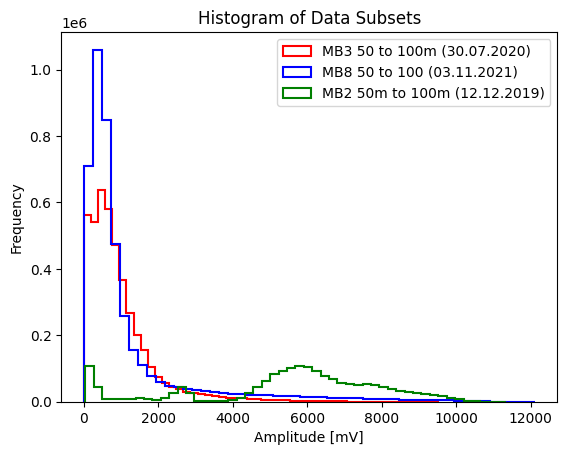

In [90]:
#normal hitstogram of the data 

import numpy as np
fig, ax = plt.subplots()

plt.hist(data_subset_MB3.ravel(), color='b',bins=50, histtype='step', edgecolor='r', alpha=1.0, linewidth=1.5, label='MB3 50 to 100m (30.07.2020)')
plt.hist(data_subset_MB8.ravel(), color='b',bins=50, histtype='step', edgecolor='b', alpha=1.0, linewidth=1.5, label='MB8 50 to 100 (03.11.2021)')
plt.hist(data_subset_MB2.ravel(), color='g',bins=50, histtype='step', edgecolor='g', alpha=1.0, linewidth=1.5, label='MB2 50m to 100m (12.12.2019)')

plt.legend()
#plt.xlabel('Travel Time [$\mu$s]') #replace with the xlabel "amplitude" when changint to travel time data
plt.xlabel('Amplitude [mV]')
#add a limit to the x avis in order to zoom in : plt.xlim(x_min, x_max)
plt.ylabel('Frequency')
plt.title('Histogram of Data Subsets')
plt.show()


In [56]:
#plot histograms of the data with a Kernel density estimation (https://en.wikipedia.org/wiki/Kernel_density_estimation) applied
import seaborn as sns #seaborn module must be installed
fig, ax = plt.subplots()
#sns.kdeplot(data_subset_MB3.ravel(), color='r', ax=ax, label='Data Subset MB3 tendency curve')
#sns.kdeplot(data_subsetMB1.ravel(), color='b', ax=ax, label='Data Subset MB1 tendency curve')
#sns.kdeplot(data_subsetMB1.ravel(), color='k', label='MB1 200m to 300m (25.01.2020)', ax=ax)
#sns.kdeplot(data_subsetMB2.ravel(), color='c', label='MB2 100m to 200m (10.12.2019)', ax=ax)
#sns.kdeplot(data_subset.ravel(), color='r', label='MB3 1m to 100m (30.07.2020)', ax=ax)



sns.kdeplot(data_subsetMB3.ravel(), color='r', label='MB3 50 to 100m (30.07.2020)', ax=ax)
sns.kdeplot(data_subseMB8.ravel(), color='b', label='ST2 100m to 200m (25.05.2021)', ax=ax)
#sns.kdeplot(data_subsetWT.ravel(), color='g', label='WT 50m to 100m (02.06.2021)', ax=ax)


plt.legend()
#plt.xlabel('Travel Time [$\mu$s]')
plt.xlabel('Amplitude [mV]')
plt.ylabel('Frequency')
plt.title('Histogram of Data Subsets')
plt.show()


ModuleNotFoundError: No module named 'seaborn'